# The t > 3 Threshold — why a 't-stat above 2' proves almost nothing 🚩
### How a factory of pure-noise 'factors' manufactures a paper's worth of discoveries — in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does t>2 inflate false discoveries?: Confirmed](https://img.shields.io/badge/Does_t%3E2_inflate_false_discoveries%3F-Confirmed-8b949e?style=flat-square)

You will read it in almost every quant paper: *"our strategy has a t-stat above 2, so the effect is real (only a 5% chance it's a fluke)."* That sentence is true — **if you tested exactly one idea**. But the finance profession has tested *hundreds* of candidate 'factors', reported the winners, and quietly buried the rest. Once you know that, a t of 2 stops being impressive.

So we run the experiment on a **factory of fake factors we built to contain nothing**: 1,000 candidate strategies, each one pure coin-flips, zero real edge. Then we ask the simple question — *how many clear the famous t > 2 bar anyway?* — and watch what happens when we raise the bar to 3.

> 📓 **This is the plain-language layer.** Want the Bonferroni / Benjamini-Yekutieli cutoffs and the publication haircut maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it, on a deterministic synthetic factor zoo. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tstat_threshold import data, strategy as st

# The whole demo runs on the deterministic, offline seed-839 factor zoo (1,000 candidate
# factors x 240 monthly periods). The NULL is pure noise; the MIXTURE plants 50 true
# factors (expected |t|=4) as a positive control. Synthetic-only by design — no real tape.
R0, _, TR0 = data.synthetic_zoo(n_factors=1000, n_periods=240, n_true=0, seed=839)
RM, IS_TRUE, TRM = data.synthetic_zoo(n_factors=1000, n_periods=240, n_true=50,
                                      expected_t=4.0, seed=839)
T0 = st.factor_tstats(R0)          # per-factor t-stats, pure-noise zoo
TM = st.factor_tstats(RM)          # per-factor t-stats, planted mixture
print("null zoo:", R0.shape, "fp", data.fingerprint(R0), "| has_edge", TR0.has_edge)
print("mixture :", RM.shape, "fp", data.fingerprint(RM), "|", int(IS_TRUE.sum()), "true factors")


null zoo: (240, 1000) fp 2a151cf27292 | has_edge False
mixture : (240, 1000) fp 7ade07aad75d | 50 true factors


## The answer first 🎯

| Question | Answer |
|---|---|
| Test 1,000 *pure-noise* factors — how many clear t > 2? | **44** of 1,000 (**4.4%**). A whole paper's worth of 'discoveries', all fake. |
| How many clear t > 3? | Just **3** (**0.3%**) — about **17× rarer**. |
| So how high should the bar be? | With a few hundred factors tested, the honest bar climbs to **~3.78** (Bonferroni). Harvey-Liu-Zhu round it to a memorable **t ≈ 3.0**. |
| Does raising the bar throw out the real stuff? | Barely. On a test with 50 *genuine* factors hidden inside, going t>2 → t>3 cuts the false-discovery rate from **46% → 7%** while keeping **82%** of the real ones. |

> A t-stat is only as meaningful as the number of things you tried. Two is the bar for *one* idea; for a zoo of hundreds, three is the honest floor.

## 1 · The claim

> *"With hundreds of factors data-mined, the usual t > 2 hurdle produces far too many false discoveries; the honest, multiple-testing-adjusted bar is about t ≈ 3.0."* — Harvey, Liu & Zhu (2016)

A **t-stat** measures how many standard errors a strategy's average return sits above zero. The convention: t above 2 ≈ 'less than 5% chance this is luck'. The catch: that 5% is *per test*. Run 100 tests on pure noise and you *expect* ~5 to clear the bar — not because they're real, but because 5% of 100 is 5.

## 2 · So what?

Because the entire published factor zoo — value, momentum, quality, and hundreds of lesser-known 'anomalies' — was selected *because* it cleared t > 2. If a big chunk of that bar is just the 5%-of-noise that had to clear it, then a large fraction of 'established' factors are mirages that will quietly vanish out-of-sample. The desk has shown you can fake an edge by **searching for a lucky backtest** ([344 Backtest-Overfitting](../../344-backtest-overfitting/)); here the search is spread across the whole *profession* testing a whole *cross-section* of factors.

## 3 · How would we even know?

We build a world where the answer is certain: **1,000 candidate factors that are pure noise** (zero-mean coin-flip returns, 240 months each). There is *nothing* real in here by construction — so every factor that clears a significance bar is, definitionally, a false discovery. Then we simply count.

## 4 · The teardown — a factory of nothing

Here is the distribution of t-stats across all 1,000 pure-noise factors. It is a bell curve centred on zero (as it must be — nothing is real). The shaded tails are the factors that clear t > 2; the darker slivers clear t > 3.

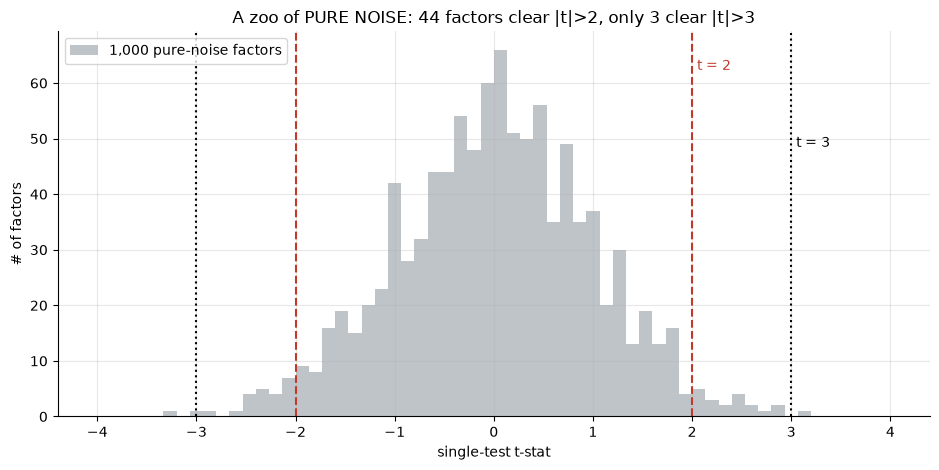

cleared |t|>2: 44/1000 (4.40%)   |   cleared |t|>3: 3/1000 (0.30%)
theory: |t|>2 -> 4.55%   |t|>3 -> 0.270%


In [2]:
t = np.abs(T0)
n2 = int((t > 2).sum()); n3 = int((t > 3).sum())
fig, ax = plt.subplots(figsize=(9.5, 4.8))
bins = np.linspace(-4, 4, 61)
ax.hist(T0, bins=bins, color=GREY, alpha=.55, label='1,000 pure-noise factors')
for c in (-2, 2):
    ax.axvline(c, color=RED, ls='--', lw=1.5)
for c in (-3, 3):
    ax.axvline(c, color='k', ls=':', lw=1.5)
ax.text(2.05, ax.get_ylim()[1]*0.9, 't = 2', color=RED)
ax.text(3.05, ax.get_ylim()[1]*0.7, 't = 3', color='k')
ax.set_xlabel('single-test t-stat'); ax.set_ylabel('# of factors')
ax.set_title(f'A zoo of PURE NOISE: {n2} factors clear |t|>2, only {n3} clear |t|>3')
ax.legend(); plt.tight_layout(); plt.show()
print(f'cleared |t|>2: {n2}/1000 ({n2/10:.2f}%)   |   cleared |t|>3: {n3}/1000 ({n3/10:.2f}%)')
print(f'theory: |t|>2 -> {st.prob_exceed(2)*100:.2f}%   |t|>3 -> {st.prob_exceed(3)*100:.3f}%')

There it is. **44 of 1,000** noise factors clear the famous t > 2 bar — that is an entire research paper of 'significant' findings conjured from coin-flips. Only **3** clear t > 3. The fractions (4.4% and 0.3%) match the textbook bell-curve tails almost exactly, because that is all they ever were.

**So how high should the bar be?** The more factors you test, the higher the bar has to rise to keep the *expected number of false discoveries* under control. This is the Bonferroni rule — and it climbs steeply with the size of the search:

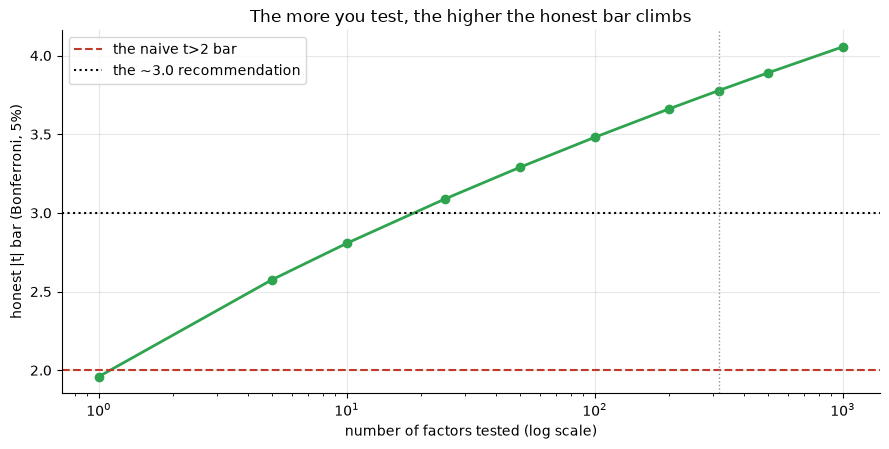

Bonferroni |t| bar:  N=1:1.96   N=10:2.81   N=100:3.48   N=316:3.78   N=1000:4.06


In [3]:
Ns = [1, 5, 10, 25, 50, 100, 200, 316, 500, 1000]
cuts = [st.bonferroni_t(n, 0.05) for n in Ns]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(Ns, cuts, 'o-', color=GREEN, lw=2)
ax.axhline(2.0, color=RED, ls='--', lw=1.5, label='the naive t>2 bar')
ax.axhline(3.0, color='k', ls=':', lw=1.5, label='the ~3.0 recommendation')
ax.axvline(316, color=GREY, ls=':', lw=1)
ax.set_xscale('log'); ax.set_xlabel('number of factors tested (log scale)')
ax.set_ylabel('honest |t| bar (Bonferroni, 5%)')
ax.set_title('The more you test, the higher the honest bar climbs')
ax.legend(); plt.tight_layout(); plt.show()
print('Bonferroni |t| bar:  ' + '   '.join(f'N={n}:{c:.2f}' for n, c in zip([1,10,100,316,1000], [st.bonferroni_t(n) for n in (1,10,100,316,1000)])))

For a single idea, the bar is the familiar **1.96**. For Harvey-Liu-Zhu's tally of **316** tested factors it is **3.78**. The round-number recommendation of **t ≈ 3.0** sits sensibly between the too-lax 2.0 and the strict 3.8.

## 5 · The verdict

- **Signal — None.** The zoo is pure noise by construction; the only 'discoveries' are the 4.4% of factors that had to clear t>2 by chance. Nothing real to detect.
- **Tradability — Mirage.** A factor that exists only because the bar was too low has no out-of-sample paycheck — that is the whole point of the haircut.
- **Does the t>2 bar inflate false discoveries? — Confirmed.** Yes — a whole paper's worth, from nothing. The honest bar is ~3.

## 6 · Could you actually 'trade' it?

This is the trap that makes the factor zoo so expensive: you *can* trade a t>2 'factor' — you just won't get paid. A factor that cleared the bar only because 4.4% of noise had to will, on average, earn zero going forward (it was never real). Worse, you'll pay real trading costs to hold it. The honest fix costs nothing: demand a t nearer 3 before you believe — and *always* ask how many other factors were tried first.

## 7 · Going further 🚪

- **The generic cousin.** [346 Multiple-Testing](../../346-multiple-testing/) is the same lesson for *any* battery of tests; this study is the factor-zoo specialisation, framed around the **3.0 hurdle** and the **publication haircut**.
- **What happens next.** [536 Anomaly-Decay-Post-Publication](../../536-anomaly-decay-post-publication/) follows factors *after* they clear the bar — and watches them fade.
- **The searching cousin.** [343 Data-Mining-Roulette](../../343-data-mining-roulette/) mines a single series for a lucky rule.

*Think your favourite anomaly is real? Fork this, plug in its t-stat and an honest count of how many factors the literature tested, and read off its publication haircut in the quants notebook.*